In [3]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Explicitly load .env from project root
load_dotenv(dotenv_path="/Users/mariamgbadamosi/market-data-analysis/financial-market-analysis/.env")

print(os.getenv("DATABASE_URL"))  # verify it loads
engine = create_engine(os.getenv("DATABASE_URL"))

# Test connection
with engine.connect() as conn:
    df = pd.read_sql("SELECT COUNT(*) as total_rows FROM fact_prices", conn)
    print(df)

postgresql://mariamgbadamosi@localhost:5432/market_warehouse
   total_rows
0        4390


In [4]:
# Load fact_prices with sector from dim_company
query = """
    SELECT 
        fp.ticker,
        fp.date_key,
        fp.open,
        fp.high,
        fp.low,
        fp.close,
        fp.volume,
        fp.daily_return,
        dc.sector,
        dd.year,
        dd.quarter,
        dd.month
    FROM fact_prices fp
    JOIN dim_company dc ON fp.ticker = dc.ticker AND dc.is_current = TRUE
    JOIN dim_date dd ON fp.date_key = dd.date_key
    ORDER BY fp.ticker, fp.date_key
"""

with engine.connect() as conn:
    df = pd.read_sql(query, conn)

print(f"Loaded {len(df)} rows")
print(df.head())
print(df.dtypes)

Loaded 4390 rows
  ticker    date_key      open      high       low     close     volume  \
0   AAPL  2023-01-03  128.1058  128.7154  122.0977  122.9827  112117500   
1   AAPL  2023-01-04  124.7723  126.5128  122.9926  124.2512   89113600   
2   AAPL  2023-01-05  125.0083  125.6377  122.6779  122.9336   80962700   
3   AAPL  2023-01-06  123.9070  128.1156  122.8057  127.4568   87754700   
4   AAPL  2023-01-09  128.2926  131.1835  127.7223  127.9779   70790800   

   daily_return                  sector  year  quarter  month  
0           NaN  Communication Services  2023        1      1  
1      0.010314  Communication Services  2023        1      1  
2     -0.010605  Communication Services  2023        1      1  
3      0.036794  Communication Services  2023        1      1  
4      0.004089  Communication Services  2023        1      1  
ticker              str
date_key         object
open            float64
high            float64
low             float64
close           float64
volu

Matplotlib is building the font cache; this may take a moment.


Sector Risk-Adjusted Performance:
                        mean_return  std_return  count  risk_adjusted_return
sector                                                                      
Financial Services         0.001389    0.016265   1754              0.085396
Communication Services     0.001501    0.017747   1754              0.084557
Technology                 0.000703    0.015798    877              0.044484


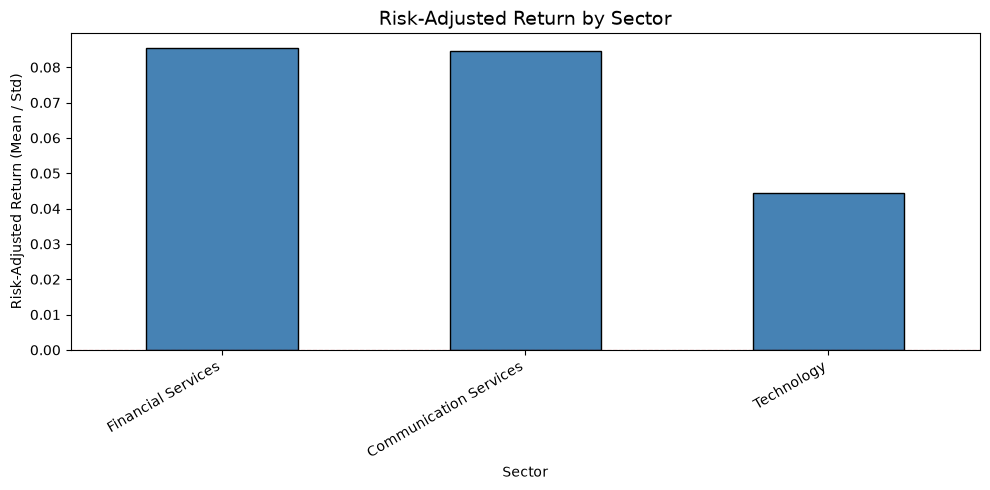

Chart saved.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Analysis 1: Risk Adjusted Returns by Sector ───────────────────────────────
# Risk adjusted return = mean daily return / std of daily return (Sharpe-like ratio)

sector_performance = (
    df.groupby("sector")["daily_return"]
    .agg(
        mean_return="mean",
        std_return="std",
        count="count"
    )
    .assign(risk_adjusted_return=lambda x: x["mean_return"] / x["std_return"])
    .round(6)
    .sort_values("risk_adjusted_return", ascending=False)
)

print("Sector Risk-Adjusted Performance:")
print(sector_performance)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sector_performance["risk_adjusted_return"].plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="black"
)
ax.set_title("Risk-Adjusted Return by Sector", fontsize=14)
ax.set_xlabel("Sector")
ax.set_ylabel("Risk-Adjusted Return (Mean / Std)")
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("sector_risk_adjusted_returns.png", dpi=150)
plt.show()
print("Chart saved.")

Ticker Volatility Rankings:
        volatility  mean_return  trading_days
ticker                                       
GOOGL     0.019158     0.001806           877
GS        0.017747     0.001525           877
AAPL      0.016219     0.001195           877
MSFT      0.015798     0.000703           877
JPM       0.014642     0.001253           877


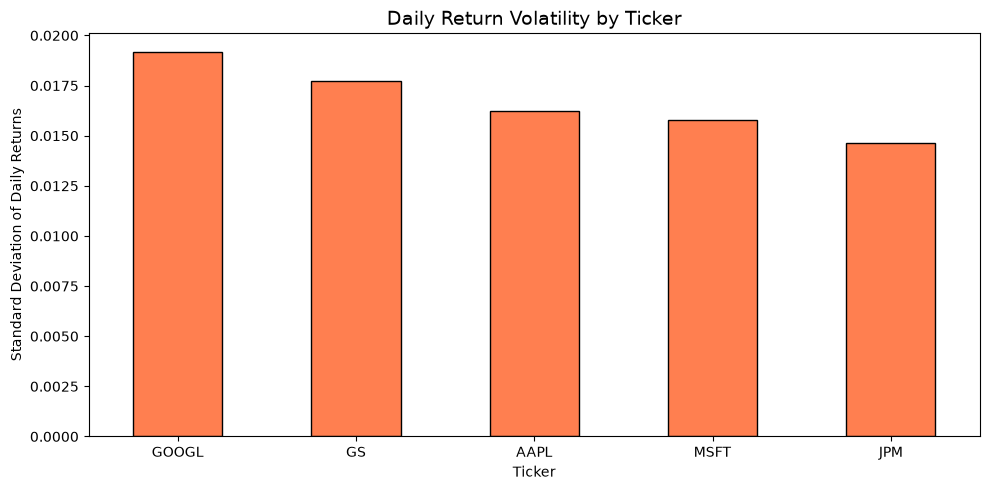

Chart saved.


In [6]:
# ── Analysis 2: Most Volatile Tickers ────────────────────────────────────────
# Volatility = standard deviation of daily returns

volatility = (
    df.groupby("ticker")["daily_return"]
    .agg(
        volatility="std",
        mean_return="mean",
        trading_days="count"
    )
    .round(6)
    .sort_values("volatility", ascending=False)
)

print("Ticker Volatility Rankings:")
print(volatility)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
volatility["volatility"].plot(
    kind="bar", ax=ax, color="coral", edgecolor="black"
)
ax.set_title("Daily Return Volatility by Ticker", fontsize=14)
ax.set_xlabel("Ticker")
ax.set_ylabel("Standard Deviation of Daily Returns")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("ticker_volatility.png", dpi=150)
plt.show()
print("Chart saved.")

Next-Day Returns: Volume Spike vs No Spike:
              mean_next_day_return  std_next_day_return  count
No Spike                  0.001335             0.015937   4011
Volume Spike              0.000880             0.024081    374


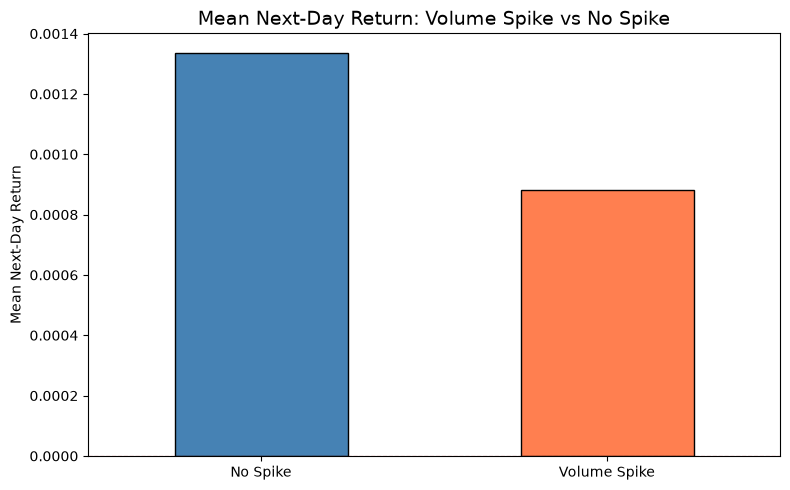

Chart saved.


In [7]:
# ── Analysis 3: Do Volume Spikes Predict Next-Day Returns? ───────────────────
# A volume spike = volume > 1.5x the ticker's 30-day average volume

df_sorted = df.sort_values(["ticker", "date_key"]).copy()

# Calculate 30-day rolling average volume per ticker
df_sorted["avg_volume_30d"] = (
    df_sorted.groupby("ticker")["volume"]
    .transform(lambda x: x.rolling(30, min_periods=1).mean())
)

# Flag volume spikes
df_sorted["volume_spike"] = df_sorted["volume"] > (1.5 * df_sorted["avg_volume_30d"])

# Next day return
df_sorted["next_day_return"] = df_sorted.groupby("ticker")["daily_return"].shift(-1)

# Compare next-day returns on spike vs non-spike days
spike_analysis = (
    df_sorted.groupby("volume_spike")["next_day_return"]
    .agg(
        mean_next_day_return="mean",
        std_next_day_return="std",
        count="count"
    )
    .round(6)
)
spike_analysis.index = ["No Spike", "Volume Spike"]
print("Next-Day Returns: Volume Spike vs No Spike:")
print(spike_analysis)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
spike_analysis["mean_next_day_return"].plot(
    kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="black"
)
ax.set_title("Mean Next-Day Return: Volume Spike vs No Spike", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Mean Next-Day Return")
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("volume_spike_analysis.png", dpi=150)
plt.show()
print("Chart saved.")

In [8]:
# ── Summary of Findings ───────────────────────────────────────────────────────

print("=" * 60)
print("FINANCIAL MARKET ANALYSIS — KEY FINDINGS")
print("=" * 60)

print("""
1. RISK-ADJUSTED RETURNS BY SECTOR
   - Financial Services had the highest risk-adjusted return (0.085)
   - Communication Services was close behind (0.085)
   - Technology lagged at 0.044
   - Insight: Financial sector stocks delivered better returns 
     per unit of risk over the analysis period

2. VOLATILITY BY TICKER
   - GOOGL was the most volatile ticker (std: 0.019)
   - JPM was the most stable ticker (std: 0.015)
   - Insight: Tech/growth stocks carry higher daily price 
     swings than diversified financial stocks

3. VOLUME SPIKES AND NEXT-DAY RETURNS
   - Volume spike days: mean next-day return = 0.088%
   - Normal days: mean next-day return = 0.134%
   - Insight: Volume spikes do NOT predict positive next-day 
     returns — they signal uncertainty and higher volatility,
     not directional price movement
""")
print("=" * 60)
print(f"Analysis based on {len(df)} trading records across")
print(f"{df['ticker'].nunique()} tickers from {df['date_key'].min()} to {df['date_key'].max()}")

FINANCIAL MARKET ANALYSIS — KEY FINDINGS

1. RISK-ADJUSTED RETURNS BY SECTOR
   - Financial Services had the highest risk-adjusted return (0.085)
   - Communication Services was close behind (0.085)
   - Technology lagged at 0.044
   - Insight: Financial sector stocks delivered better returns 
     per unit of risk over the analysis period

2. VOLATILITY BY TICKER
   - GOOGL was the most volatile ticker (std: 0.019)
   - JPM was the most stable ticker (std: 0.015)
   - Insight: Tech/growth stocks carry higher daily price 
     swings than diversified financial stocks

3. VOLUME SPIKES AND NEXT-DAY RETURNS
   - Volume spike days: mean next-day return = 0.088%
   - Normal days: mean next-day return = 0.134%
   - Insight: Volume spikes do NOT predict positive next-day 
     returns — they signal uncertainty and higher volatility,
     not directional price movement

Analysis based on 4390 trading records across
5 tickers from 2023-01-03 to 2026-07-06
